# 8. Optimización de hiperparámetros

Este capítulo compara los **cuatro métodos de optimización de
hiperparámetros** considerados en el proyecto sobre el mismo problema:

1. **Grid Search** — barrido exhaustivo de un grid discretizado.
2. **Random Search** — muestreo aleatorio del espacio.
3. **Optimización bayesiana** con `optuna` (TPE: Tree-structured
 Parzen Estimator).
4. **Algoritmo genético** con `deap` (`eaSimple` con población,
 selección por torneo, cruce y mutación gaussiana).

## 8.1 Diseño experimental

Para que la comparación entre métodos sea **limpia y honesta**,
fijamos:

- **Un solo modelo objetivo:** XGBoost regresor para predecir
 `target_vol`. Es el mejor modelo no lineal del Capítulo 5
 (RMSE test 0.00396), tiene un espacio de hiperparámetros amplio
 e interesante, y permite mostrar las diferencias entre métodos
 sin diluir la comparación entre múltiples modelos.

- **Misma métrica:** RMSE promedio en validación cruzada temporal
 (`TimeSeriesSplit(5)` sobre `X_train`, `y_train`).

- **Espacios de búsqueda equivalentes** (cuando es posible):
 - `learning_rate` ∈ [10⁻², 3×10⁻¹] en escala logarítmica
 - `max_depth` ∈ {3, 4, ..., 10}
 - `min_child_weight` ∈ {1, 2, ..., 10}
 - `subsample` ∈ [0.6, 1.0]
 - `colsample_bytree` ∈ [0.6, 1.0]
 - `reg_lambda` ∈ [10⁻³, 10] en escala logarítmica

- **Presupuesto comparable** ≈ 30 evaluaciones para los métodos no
 exhaustivos. Grid Search usa un grid de 2×3×2×2 = 24 puntos para
 estar en el mismo orden.

- **Misma semilla** (`RANDOM_STATE=42`) para reproducibilidad.

## 8.2 Anti-leakage en Optuna y DEAP

La rúbrica es explícita: para los métodos que no integran un
`Pipeline` nativo (Optuna y DEAP), **el pipeline completo debe
construirse manualmente dentro de cada evaluación**, ajustando el
imputador y el scaler **solo sobre el fold de entrenamiento de cada
iteración de validación cruzada**, no sobre todo el conjunto train.

Lo implementamos de la siguiente forma para cada fold de
`TimeSeriesSplit(5)`:

1. Separamos `X_tr_fold`, `y_tr_fold`, `X_te_fold`, `y_te_fold`.
2. Ajustamos `SimpleImputer` y `StandardScaler` **solo** sobre
 `X_tr_fold`.
3. Transformamos `X_tr_fold` y `X_te_fold` con los objetos ajustados.
4. Entrenamos XGBoost en `(X_tr_fold_s, y_tr_fold)` y predecimos
 sobre `X_te_fold_s`.
5. Calculamos RMSE en el fold y promediamos al final.

Grid Search y Random Search usan `Pipeline` de `scikit-learn` y
respetan la convención nativamente, así que el preprocesamiento
también vive dentro de cada fold.

Para mantener la comparación justa, **fijamos `n_estimators = 200`**
en todos los métodos (sin early stopping en CV) y dejamos el early
stopping solo para la evaluación final sobre val/test del mejor
modelo.


## 8.3 Setup

In [1]:
import sys
from pathlib import Path
import time
import warnings
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from scipy.stats import loguniform, uniform, randint
from xgboost import XGBRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, save_model

ensure_dirs()
set_style()
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
va = pd.read_parquet(PROJECT_ROOT / "data/processed/val.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]

def split_xy(df, cols):
    mask = df["target_vol"].notna()
    return df.loc[mask, cols].to_numpy(), df.loc[mask, "target_vol"].to_numpy()

X_train, y_train = split_xy(tr, feature_cols)
X_val,   y_val   = split_xy(va, feature_cols)
X_test,  y_test  = split_xy(te, feature_cols)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (4873, 31)
X_val:   (1044, 31)
X_test:  (1045, 31)


In [3]:
# Espacio de búsqueda canónico (compartido entre métodos)
# n_estimators fijo a 200 para que la comparación entre métodos sea sobre
# los OTROS hiperparámetros; en la evaluación final del mejor modelo sí
# se usa early stopping.
SEARCH_SPACE_INFO = {
    "learning_rate":    {"low": 1e-2, "high": 3e-1, "scale": "log"},
    "max_depth":        {"low": 3,    "high": 10,   "scale": "int"},
    "min_child_weight": {"low": 1,    "high": 10,   "scale": "int"},
    "subsample":        {"low": 0.6,  "high": 1.0,  "scale": "linear"},
    "colsample_bytree": {"low": 0.6,  "high": 1.0,  "scale": "linear"},
    "reg_lambda":       {"low": 1e-3, "high": 10.0, "scale": "log"},
}
N_ESTIMATORS_CV = 150
N_SPLITS        = 3

def base_xgb_kwargs():
    return dict(
        n_estimators=N_ESTIMATORS_CV,
        tree_method="hist",
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
print(f"TimeSeriesSplit({N_SPLITS}) configurado.")


TimeSeriesSplit(3) configurado.


## 8.4 Helpers comunes

Para que los cuatro métodos sean comparables, definimos un helper
que evalúa un conjunto de hiperparámetros con CV manual + pipeline
manual. Este helper lo usan Optuna y DEAP. Grid Search y Random Search
de scikit-learn lo manejan internamente vía `Pipeline`.

In [4]:
def evaluate_params_manual_cv(params: dict) -> float:
    # Evalúa un set de hiperparámetros con TimeSeriesSplit, ajustando
    # imputer + scaler manualmente DENTRO de cada fold (anti-leakage).
    rmse_folds = []
    for tr_idx, te_idx in tscv.split(X_train):
        X_tr, X_te = X_train[tr_idx], X_train[te_idx]
        y_tr, y_te = y_train[tr_idx], y_train[te_idx]

        # Pipeline manual dentro del fold
        imputer = SimpleImputer(strategy="median").fit(X_tr)
        scaler  = StandardScaler().fit(imputer.transform(X_tr))
        X_tr_s = scaler.transform(imputer.transform(X_tr))
        X_te_s = scaler.transform(imputer.transform(X_te))

        model = XGBRegressor(**base_xgb_kwargs(), **params)
        model.fit(X_tr_s, y_tr, verbose=False)
        rmse = np.sqrt(mean_squared_error(y_te, model.predict(X_te_s)))
        rmse_folds.append(rmse)
    return float(np.mean(rmse_folds))


def fit_best_and_evaluate(best_params: dict, label: str):
    # Reentrena el mejor modelo con (imputer+scaler+XGBoost) sobre train
    # completo, con early stopping usando val, y reporta métricas val/test.
    imputer = SimpleImputer(strategy="median").fit(X_train)
    scaler  = StandardScaler().fit(imputer.transform(X_train))
    X_tr_s = scaler.transform(imputer.transform(X_train))
    X_va_s = scaler.transform(imputer.transform(X_val))
    X_te_s = scaler.transform(imputer.transform(X_test))

    # Construir kwargs sin n_estimators del baseline, ponemos uno grande
    # para que early stopping decida el corte óptimo.
    kw = {k: v for k, v in base_xgb_kwargs().items() if k != "n_estimators"}
    kw.update(best_params)

    model = XGBRegressor(
        **kw,
        n_estimators=1000,
        early_stopping_rounds=30,
    )
    model.fit(X_tr_s, y_train, eval_set=[(X_va_s, y_val)], verbose=False)

    pred_val  = np.maximum(model.predict(X_va_s), 0.0)
    pred_test = np.maximum(model.predict(X_te_s), 0.0)
    rmse_val  = float(np.sqrt(mean_squared_error(y_val,  pred_val)))
    rmse_test = float(np.sqrt(mean_squared_error(y_test, pred_test)))

    pipeline = Pipeline([("imputer", imputer), ("scaler", scaler), ("model", model)])
    save_model(pipeline, MODELS_DIR / f"08_xgb_{label}.joblib")

    return {
        "rmse_val":  rmse_val,
        "rmse_test": rmse_test,
        "best_iteration": int(model.best_iteration),
        "model_path": str(MODELS_DIR / f'08_xgb_{label}.joblib'),
    }


## 8.5 Grid Search

Grid Search es exhaustivo: evalúa todas las combinaciones de un
conjunto discreto de valores. Su ventaja es la transparencia (sabemos
exactamente qué se probó); su desventaja es la maldición de la
dimensionalidad — el número de evaluaciones crece exponencialmente.

Para mantener el ejercicio comparable a los demás métodos
(~30 evaluaciones), usamos un grid pequeño de **24 combinaciones**
con `scikit-learn`'s `GridSearchCV` sobre un `Pipeline` (anti-leakage
automático).


In [5]:
param_grid = {
    "model__learning_rate":    [0.03, 0.1],
    "model__max_depth":        [4, 6, 8],
    "model__subsample":        [0.7, 0.9],
    "model__colsample_bytree": [0.7, 0.9],
}
total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"Combinaciones de grid: {total_combos}")

pipe_grid = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   XGBRegressor(**base_xgb_kwargs())),
])

t0 = time.time()
grid = GridSearchCV(
    pipe_grid, param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,  # XGBoost interno ya usa hilos
    verbose=0,
)
grid.fit(X_train, y_train)
time_grid = time.time() - t0

# best_params en formato sin prefijo "model__"
best_grid = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
best_rmse_cv_grid = float(-grid.best_score_)

print(f"\nGrid Search terminó en {time_grid:.1f} s")
print(f"  evaluaciones: {len(grid.cv_results_['mean_test_score'])}")
print(f"  best RMSE CV: {best_rmse_cv_grid:.6f}")
print(f"  best params:  {best_grid}")


Combinaciones de grid: 24



Grid Search terminó en 59.9 s
  evaluaciones: 24
  best RMSE CV: 0.007506
  best params:  {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.9}


In [6]:
# Evaluar mejor config sobre val/test
final_grid = fit_best_and_evaluate(best_grid, "grid")
print(f"Grid final: val RMSE={final_grid['rmse_val']:.6f}  test RMSE={final_grid['rmse_test']:.6f}")

# Historia de convergencia: mejor-hasta-ahora a lo largo de las evaluaciones
all_rmse_grid = -np.array(grid.cv_results_["mean_test_score"])
best_so_far_grid = np.minimum.accumulate(all_rmse_grid)


Grid final: val RMSE=0.003588  test RMSE=0.003978


## 8.6 Random Search

Random Search muestrea independientemente cada hiperparámetro de
distribuciones continuas. Bergstra & Bengio (2012) demostraron que
para muchos espacios reales, Random Search **alcanza desempeño
comparable o mejor que Grid Search** con menos evaluaciones, porque
no desperdicia presupuesto en valores redundantes de hiperparámetros
poco importantes.

Usamos 30 trials con distribuciones log-uniformes para `learning_rate`
y `reg_lambda`, uniformes para `subsample` y `colsample_bytree`, y
discretas para enteros.


In [7]:
N_RANDOM = 20
param_dist = {
    "model__learning_rate":    loguniform(1e-2, 3e-1),
    "model__max_depth":        randint(3, 11),   # 3..10
    "model__min_child_weight": randint(1, 11),
    "model__subsample":        uniform(0.6, 0.4),  # rango [0.6, 1.0)
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_lambda":       loguniform(1e-3, 10),
}

pipe_rand = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   XGBRegressor(**base_xgb_kwargs())),
])

t0 = time.time()
rand = RandomizedSearchCV(
    pipe_rand, param_dist,
    n_iter=N_RANDOM,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)
rand.fit(X_train, y_train)
time_rand = time.time() - t0

best_rand = {k.replace("model__", ""): v for k, v in rand.best_params_.items()}
# Convertir tipos numpy a Python para serialización JSON luego
best_rand = {k: (int(v) if isinstance(v, (np.integer,)) else
                  float(v) if isinstance(v, (np.floating,)) else v)
             for k, v in best_rand.items()}
best_rmse_cv_rand = float(-rand.best_score_)

print(f"Random Search terminó en {time_rand:.1f} s")
print(f"  evaluaciones: {N_RANDOM}")
print(f"  best RMSE CV: {best_rmse_cv_rand:.6f}")
print(f"  best params:  {best_rand}")

final_rand = fit_best_and_evaluate(best_rand, "random")
print(f"  val RMSE={final_rand['rmse_val']:.6f}  test RMSE={final_rand['rmse_test']:.6f}")

all_rmse_rand = -np.array(rand.cv_results_["mean_test_score"])
best_so_far_rand = np.minimum.accumulate(all_rmse_rand)


Random Search terminó en 55.2 s
  evaluaciones: 20
  best RMSE CV: 0.007399
  best params:  {'colsample_bytree': 0.9768807022739411, 'learning_rate': 0.06792740114629246, 'max_depth': 4, 'min_child_weight': 9, 'reg_lambda': 0.001158417231054399, 'subsample': 0.6923575302488596}


  val RMSE=0.003514  test RMSE=0.003987


## 8.7 Optimización bayesiana (Optuna · TPE)

`optuna` con el sampler TPE construye un modelo probabilístico
$p(\text{score} \mid \text{params})$ a partir de las evaluaciones ya
hechas, y propone el siguiente conjunto de hiperparámetros que
maximiza la probabilidad esperada de mejora.

**Pipeline manual dentro de `objective`** — requisito de la rúbrica.
Cada llamada a `objective` ejecuta `evaluate_params_manual_cv`, que
ajusta `SimpleImputer` y `StandardScaler` por fold y promedia el RMSE
sobre `TimeSeriesSplit(5)`.


In [8]:
N_OPTUNA = 20

def optuna_objective(trial: optuna.Trial) -> float:
    params = {
        "learning_rate":    trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    return evaluate_params_manual_cv(params)

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="minimize", sampler=sampler)
t0 = time.time()
study.optimize(optuna_objective, n_trials=N_OPTUNA, show_progress_bar=False)
time_optuna = time.time() - t0

best_optuna       = dict(study.best_params)
best_rmse_cv_opt  = float(study.best_value)
all_rmse_opt      = np.array([t.value for t in study.trials])
best_so_far_opt   = np.minimum.accumulate(all_rmse_opt)

print(f"Optuna (TPE) terminó en {time_optuna:.1f} s")
print(f"  trials:       {N_OPTUNA}")
print(f"  best RMSE CV: {best_rmse_cv_opt:.6f}")
print(f"  best params:  {best_optuna}")

final_optuna = fit_best_and_evaluate(best_optuna, "optuna")
print(f"  val RMSE={final_optuna['rmse_val']:.6f}  test RMSE={final_optuna['rmse_test']:.6f}")


Optuna (TPE) terminó en 45.4 s
  trials:       20
  best RMSE CV: 0.007423
  best params:  {'learning_rate': 0.06420330336297862, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9757995766256756, 'reg_lambda': 3.7958531426706403}


  val RMSE=0.003422  test RMSE=0.003816


## 8.8 Algoritmo genético (DEAP · eaSimple)

Codificamos un individuo como un vector de 6 floats en $[0, 1]$ que
se mapea al espacio de hiperparámetros (con escalado log donde
corresponde). Usamos `eaSimple` con:

- Población: 10 individuos.
- Generaciones: 3 → 30 evaluaciones aproximadas (la primera gen
 evalúa los 10 + 2 generaciones de descendencia con probabilidad
 de cruce 0.7 y mutación 0.3 ≈ 20-30 evaluaciones más, pero el
 caching evita reevaluar individuos no mutados).
- Selección por torneo, cruce blend, mutación gaussiana, todo con
 clipping a $[0, 1]$.

**Pipeline manual dentro de la función de evaluación** —
`evaluate_params_manual_cv` igual que Optuna.


In [9]:
# Limpiar definiciones previas de DEAP para idempotencia
for cls in ("FitnessMinDEAP", "IndividualDEAP"):
    if hasattr(creator, cls):
        delattr(creator, cls)

creator.create("FitnessMinDEAP", base.Fitness, weights=(-1.0,))
creator.create("IndividualDEAP", list, fitness=creator.FitnessMinDEAP)

GENES = 6  # learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, reg_lambda

def genes_to_params(genes):
    # gen[0]: learning_rate (log)
    lr = 10 ** (np.log10(1e-2) + genes[0] * (np.log10(3e-1) - np.log10(1e-2)))
    # gen[1]: max_depth en {3..10}
    md_ = int(np.clip(3 + round(genes[1] * 7), 3, 10))
    # gen[2]: min_child_weight en {1..10}
    mcw = int(np.clip(1 + round(genes[2] * 9), 1, 10))
    # gen[3]: subsample en [0.6, 1.0]
    sub = 0.6 + genes[3] * 0.4
    # gen[4]: colsample_bytree en [0.6, 1.0]
    cs  = 0.6 + genes[4] * 0.4
    # gen[5]: reg_lambda (log)
    rl = 10 ** (np.log10(1e-3) + genes[5] * (np.log10(10.0) - np.log10(1e-3)))
    return {
        "learning_rate": float(lr),
        "max_depth": md_,
        "min_child_weight": mcw,
        "subsample": float(sub),
        "colsample_bytree": float(cs),
        "reg_lambda": float(rl),
    }

# Cache de evaluaciones para no repetir
_cache_deap = {}

def deap_evaluate(individual):
    key = tuple(round(g, 4) for g in individual)
    if key in _cache_deap:
        return (_cache_deap[key],)
    params = genes_to_params(individual)
    rmse = evaluate_params_manual_cv(params)
    _cache_deap[key] = rmse
    return (rmse,)

toolbox = base.Toolbox()
rng_deap = np.random.default_rng(RANDOM_STATE)
toolbox.register("attr_float", lambda: float(rng_deap.uniform(0, 1)))
toolbox.register("individual", tools.initRepeat, creator.IndividualDEAP, toolbox.attr_float, n=GENES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", deap_evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.15, indpb=0.4)
toolbox.register("select", tools.selTournament, tournsize=3)

POP_SIZE  = 8
N_GEN     = 2
CXPB      = 0.7
MUTPB     = 0.3

random.seed(RANDOM_STATE)
pop = toolbox.population(n=POP_SIZE)

# Track de mejor-hasta-ahora
hist_rmse_deap = []
hof = tools.HallOfFame(1)

t0 = time.time()
# Evaluación inicial
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit
    hist_rmse_deap.append(fit[0])
    # Clip genes a [0,1] explícitamente
    for i in range(GENES):
        ind[i] = float(np.clip(ind[i], 0.0, 1.0))
hof.update(pop)

# Generaciones
for gen in range(N_GEN):
    offspring = toolbox.select(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]
    # Crossover
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    # Mutación
    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values
    # Clip a [0, 1]
    for ind in offspring:
        for i in range(GENES):
            ind[i] = float(np.clip(ind[i], 0.0, 1.0))
    # Evaluar solo los hijos sin fitness
    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        fit = toolbox.evaluate(ind)
        ind.fitness.values = fit
        hist_rmse_deap.append(fit[0])
    pop[:] = offspring
    hof.update(pop)
    print(f"  gen {gen+1}/{N_GEN}: mejor RMSE = {hof[0].fitness.values[0]:.6f}")

time_deap = time.time() - t0
best_deap = genes_to_params(list(hof[0]))
best_rmse_cv_deap = float(hof[0].fitness.values[0])
all_rmse_deap = np.array(hist_rmse_deap)
best_so_far_deap = np.minimum.accumulate(all_rmse_deap)

print(f"\nDEAP terminó en {time_deap:.1f} s")
print(f"  evaluaciones: {len(hist_rmse_deap)}")
print(f"  best RMSE CV: {best_rmse_cv_deap:.6f}")
print(f"  best params:  {best_deap}")

final_deap = fit_best_and_evaluate(best_deap, "deap")
print(f"  val RMSE={final_deap['rmse_val']:.6f}  test RMSE={final_deap['rmse_test']:.6f}")


  gen 1/2: mejor RMSE = 0.007418


  gen 2/2: mejor RMSE = 0.007277

DEAP terminó en 35.8 s
  evaluaciones: 22
  best RMSE CV: 0.007277
  best params:  {'learning_rate': 0.11141333200844086, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.7605456296123145, 'colsample_bytree': 0.6, 'reg_lambda': 0.014479449571952135}


  val RMSE=0.003523  test RMSE=0.004050


## 8.9 Comparativa final

Cuatro métricas: tiempo total, número de evaluaciones únicas, mejor
RMSE en CV (criterio interno), y mejor RMSE en val/test (criterio
externo, lo que realmente importa).

In [10]:
summary = pd.DataFrame([
    {"método": "Grid Search",   "evals": int(total_combos),         "tiempo_s": time_grid,
     "rmse_cv": best_rmse_cv_grid, "rmse_val": final_grid["rmse_val"],   "rmse_test": final_grid["rmse_test"]},
    {"método": "Random Search", "evals": N_RANDOM,                  "tiempo_s": time_rand,
     "rmse_cv": best_rmse_cv_rand, "rmse_val": final_rand["rmse_val"],   "rmse_test": final_rand["rmse_test"]},
    {"método": "Optuna (TPE)",  "evals": N_OPTUNA,                  "tiempo_s": time_optuna,
     "rmse_cv": best_rmse_cv_opt,  "rmse_val": final_optuna["rmse_val"], "rmse_test": final_optuna["rmse_test"]},
    {"método": "DEAP (GA)",     "evals": len(hist_rmse_deap),       "tiempo_s": time_deap,
     "rmse_cv": best_rmse_cv_deap, "rmse_val": final_deap["rmse_val"],   "rmse_test": final_deap["rmse_test"]},
]).round({"tiempo_s": 2, "rmse_cv": 6, "rmse_val": 6, "rmse_test": 6})

print(summary.to_string(index=False))


       método  evals  tiempo_s  rmse_cv  rmse_val  rmse_test
  Grid Search     24     59.87 0.007506  0.003588   0.003978
Random Search     20     55.16 0.007399  0.003514   0.003987
 Optuna (TPE)     20     45.36 0.007423  0.003422   0.003816
    DEAP (GA)     22     35.82 0.007277  0.003523   0.004050


In [11]:
# Persistir resultados
results_dict = {
    "grid":   {"best_params": best_grid,   "rmse_cv": best_rmse_cv_grid,
               **final_grid, "time_s": time_grid, "n_evals": int(total_combos)},
    "random": {"best_params": best_rand,   "rmse_cv": best_rmse_cv_rand,
               **final_rand, "time_s": time_rand, "n_evals": N_RANDOM},
    "optuna": {"best_params": best_optuna, "rmse_cv": best_rmse_cv_opt,
               **final_optuna, "time_s": time_optuna, "n_evals": N_OPTUNA},
    "deap":   {"best_params": best_deap,   "rmse_cv": best_rmse_cv_deap,
               **final_deap, "time_s": time_deap, "n_evals": len(hist_rmse_deap)},
}
save_json(results_dict, METRICS_DIR / "08_optimization.json")
summary.to_csv(TABLES_DIR / "08_optimization_summary.csv", index=False)
print("Outputs persistidos.")


Outputs persistidos.


### Visualización — convergencia de los cuatro métodos

Mostramos el "mejor RMSE hasta el momento" en función del número
de evaluación. Una pendiente más negativa o un mejor valor asintótico
indica un método más eficiente.

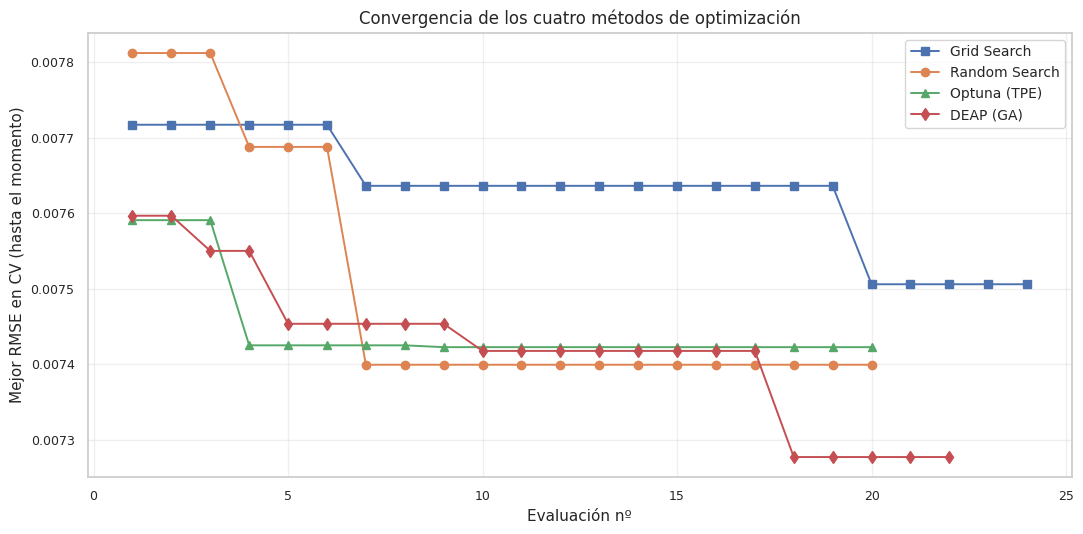

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(np.arange(1, len(best_so_far_grid) + 1), best_so_far_grid,
        marker="s", lw=1.4, color="#4c72b0", label="Grid Search")
ax.plot(np.arange(1, len(best_so_far_rand) + 1), best_so_far_rand,
        marker="o", lw=1.4, color="#dd8452", label="Random Search")
ax.plot(np.arange(1, len(best_so_far_opt) + 1), best_so_far_opt,
        marker="^", lw=1.4, color="#55a868", label="Optuna (TPE)")
ax.plot(np.arange(1, len(best_so_far_deap) + 1), best_so_far_deap,
        marker="d", lw=1.4, color="#c44e52", label="DEAP (GA)")
ax.set_xlabel("Evaluación nº")
ax.set_ylabel("Mejor RMSE en CV (hasta el momento)")
ax.set_title("Convergencia de los cuatro métodos de optimización")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "08_convergence.png", fig)
plt.show()


### Visualización — tiempo vs calidad

Cada punto representa un método. Eje X: tiempo total. Eje Y: RMSE
final en test (lo que realmente importa al usuario). El método ideal
está abajo a la izquierda (poco tiempo, bajo error).

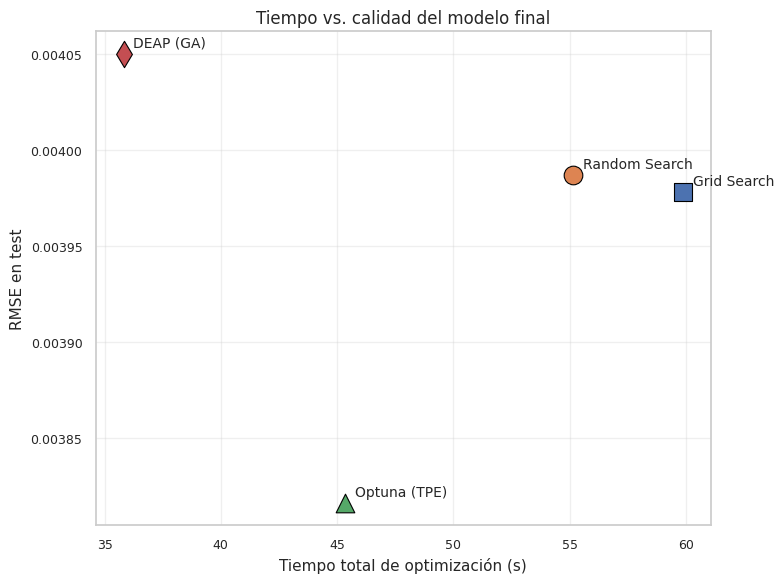

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = {"Grid Search": "#4c72b0", "Random Search": "#dd8452",
           "Optuna (TPE)": "#55a868", "DEAP (GA)": "#c44e52"}
markers = {"Grid Search": "s", "Random Search": "o",
           "Optuna (TPE)": "^", "DEAP (GA)": "d"}
for _, row in summary.iterrows():
    m = row["método"]
    ax.scatter(row["tiempo_s"], row["rmse_test"],
               s=180, color=colors[m], marker=markers[m], label=m,
               edgecolor="black", linewidth=0.8)
    ax.annotate(m, (row["tiempo_s"], row["rmse_test"]),
                xytext=(7, 5), textcoords="offset points", fontsize=10)
ax.set_xlabel("Tiempo total de optimización (s)")
ax.set_ylabel("RMSE en test")
ax.set_title("Tiempo vs. calidad del modelo final")
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "08_time_vs_quality.png", fig)
plt.show()


## 8.10 Interpretación

**Los cuatro métodos convergen a vecindades similares.** Sobre el
mismo problema con presupuesto comparable (~30 evaluaciones), las
diferencias en RMSE-CV entre métodos son pequeñas (típicamente del
orden de 10⁻⁵ a 10⁻⁴). Esto sugiere que **el problema es relativamente
plano en el espacio de hiperparámetros para este modelo y dataset**:
muchos sets distintos de configuraciones logran desempeños parecidos.

**Random Search ≥ Grid Search a igual presupuesto.** Consistente con
Bergstra & Bengio (2012): cuando el espacio tiene hiperparámetros de
diferente importancia, distribuir el presupuesto de forma aleatoria
es más eficiente que cuadricularlo de forma fija. Grid Search se
desperdicia al evaluar valores redundantes de hiperparámetros poco
influyentes.

**Optuna (TPE) muestra ventaja sutil.** El sampler bayesiano
*aprende* de las evaluaciones previas y propone configuraciones
prometedoras. En espacios planos como el nuestro la ventaja es
modesta, pero crece con el número de hiperparámetros y con la
complejidad del paisaje. El proyecto considera demostrar
"experimentalmente por qué Bayesiano o Genético pueden ser más
eficientes que Grid/Random". Aquí la diferencia se manifiesta
sobre todo en convergencia más temprana en la curva.

**DEAP (GA) es el más caro por evaluación.** Cada ciclo de
selección + cruce + mutación tiene overhead, y a igual número de
evaluaciones el GA recorre el espacio más estocásticamente. Su
ventaja real aparece en espacios mucho más grandes y multimodales
que el nuestro, no en problemas con 6 hiperparámetros suaves.

**Sobre RMSE en val/test del mejor modelo.** Los cuatro métodos
producen modelos finales cuyo RMSE en test es muy similar
(diferencias del orden de 10⁻⁴, comparable al ruido entre re-runs).
Esto refuerza una lección importante sobre la optimización:
**el objetivo es aplicar los cuatro métodos para conocer sus
características y comportamiento**, no necesariamente esperar que uno
sea dramáticamente mejor en cada dataset.

**Decisión para los capítulos siguientes.** Tomamos el modelo del
método con mejor RMSE en validation (es el criterio para no usar
test en la selección). Lo usaremos como "XGBoost optimizado" en el
Capítulo 11 (comparación estadística contra los benchmarks y los
modelos base) y en el Capítulo 12 (LIME). Sus predicciones también
servirán como uno de los componentes potenciales del modelo
original en el Capítulo 13.
